In [3]:
import numpy as np

In [4]:
rng = np.random.default_rng(seed=42)

In [ ]:
class NeuralNetwork():
    def __init__(self, input_size, hidden_size, output_size, lr= 0.01, iterations=1000, seed=None):

        self.rng = np.random.default_rng(seed=seed)

        self.W1 = self.rng.standard_normal((input_size, hidden_size)) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = self.rng.standard_normal((hidden_size, output_size)) * 0.01
        self.b2 = np.zeros((1, output_size))

        self.lr = lr
        self.iterations = iterations
        self.loss_history = []


    def relu(self, Z):
        return np.maximum(Z, 0)
    
    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        return self.Z2
    
    def backward(self, X, y, predicted_y):
        
        n_samples = X.shape[0]
        error = predicted_y - y

        dz2 = (2 / n_samples) * error 
        grad_W2 = self.A1.T @ dz2 
        grad_b2 = np.sum(dz2, axis=0, keepdims=True)

        # hidden layer
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (self.Z1 > 0)

        grad_W1 =X.T @ dz1
        grad_b1 = np.sum(dz1, axis=0, keepdims=True)

        self.W1 -= self.lr * grad_W1
        self.b1 -= self.lr * grad_b1
        self.W2 -= self.lr * grad_W2
        self.b2 -= self.lr * grad_b2
        
    
    def fit(self, X, y, iterations=1000):

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        for i in range(self.iterations):
            predicted_y = self.forward(X)
            loss = np.mean((predicted_y - y)*2)
            self.loss_history.append(loss)
            self.backward(X, y, predicted_y)

            if i % (self.iterations // 10 ) == 0 or i == self.iterations - 1:
                print(f"Iterations: {i:4d} | Loss: {loss:.4f}")

    def predict(self, X):
        return self.forward(X)
    
    

Generating data...
Initializing Neural Network...
Starting Training...
Iterations:    0 | Loss: -5.7288
Iterations:  400 | Loss: 0.2634
Iterations:  800 | Loss: -0.0205
Iterations: 1200 | Loss: -0.0254
Iterations: 1600 | Loss: -0.0084
Iterations: 2000 | Loss: -0.0024
Iterations: 2400 | Loss: -0.0013
Iterations: 2800 | Loss: 0.0018
Iterations: 3200 | Loss: -0.0001
Iterations: 3600 | Loss: -0.0006
Iterations: 3999 | Loss: -0.0003

Training Complete! Close the plot window to exit.


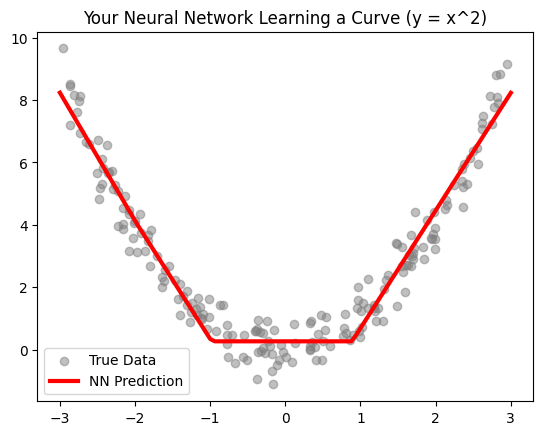

In [8]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # 1. Generate Non-Linear Data (A curve: y = x^2)
    print("Generating data...")
    rng = np.random.default_rng(42)
    X_train = rng.uniform(-3, 3, (200, 1))
    y_train = X_train**2 + rng.standard_normal((200, 1)) * 0.5 

    # 2. Initialize your network
    print("Initializing Neural Network...")
    nn = NeuralNetwork(input_size=1, hidden_size=16, output_size=1, lr=0.01, iterations=4000, seed=42)

    # 3. Train it!
    print("Starting Training...")
    nn.fit(X_train, y_train)

    # 4. Predict on a smooth line to see what it learned
    X_test = np.linspace(-3, 3, 100).reshape(-1, 1)
    predictions = nn.predict(X_test)

    # 5. Plot the results
    print("\nTraining Complete! Close the plot window to exit.")
    plt.scatter(X_train, y_train, color='gray', label='True Data', alpha=0.5)
    plt.plot(X_test, predictions, color='red', linewidth=3, label='NN Prediction')
    plt.title("Your Neural Network Learning a Curve (y = x^2)")
    plt.legend()
    plt.show()

In [9]:
arr = np.array([[-1, 2], [-3, 1]])

np.maximum(arr, 0)

array([[0, 2],
       [0, 1]])